In [1]:
import sys
sys.path.append('..')  # чтобы видеть src/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
import shutil
import random
from pathlib import Path

# Наш модуль
from src.dataset import build_class_mapping, PlantDiseaseDataset, IMAGENET_MEAN, IMAGENET_STD

# Настройки графиков
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Пути
DATA_ROOT = Path("../data/raw")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


In [2]:
def scan_dataset(root: Path) -> pd.DataFrame:
    """Сканирует папку и возвращает DataFrame с инфой о каждом изображении."""
    records = []
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                # Парсим название класса
                parts = class_dir.name.split("___")
                plant    = parts[0].replace("_", " ") if len(parts) > 0 else "Unknown"
                disease  = parts[1].replace("_", " ") if len(parts) > 1 else "Unknown"
                is_healthy = "healthy" in class_dir.name.lower()

                records.append({
                    "class"      : class_dir.name,
                    "plant"      : plant,
                    "disease"    : disease,
                    "is_healthy" : is_healthy,
                    "path"       : str(img_path),
                    "size_kb"    : img_path.stat().st_size / 1024,
                    "split"      : root.name,
                })
    return pd.DataFrame(records)

# Сканируем все сплиты
df_train = scan_dataset(DATA_ROOT / "train")
df_valid = scan_dataset(DATA_ROOT / "valid")
df_test  = scan_dataset(DATA_ROOT / "test")
df_all   = pd.concat([df_train, df_valid, df_test], ignore_index=True)

print(f"{'Split':<8} {'Images':>8} {'Classes':>8}")
print("-" * 28)
print(f"{'Train':<8} {len(df_train):>8,} {df_train['class'].nunique():>8}")
print(f"{'Valid':<8} {len(df_valid):>8,} {df_valid['class'].nunique():>8}")
print(f"{'Test':<8}  {len(df_test):>8,}  {df_test['class'].nunique():>8}")
print("-" * 28)
print(f"{'Total':<8} {len(df_all):>8,} {df_all['class'].nunique():>8}")

Split      Images  Classes
----------------------------
Train      70,295       38
Valid      17,572       38
Test         1,742        38
----------------------------
Total      89,609       38


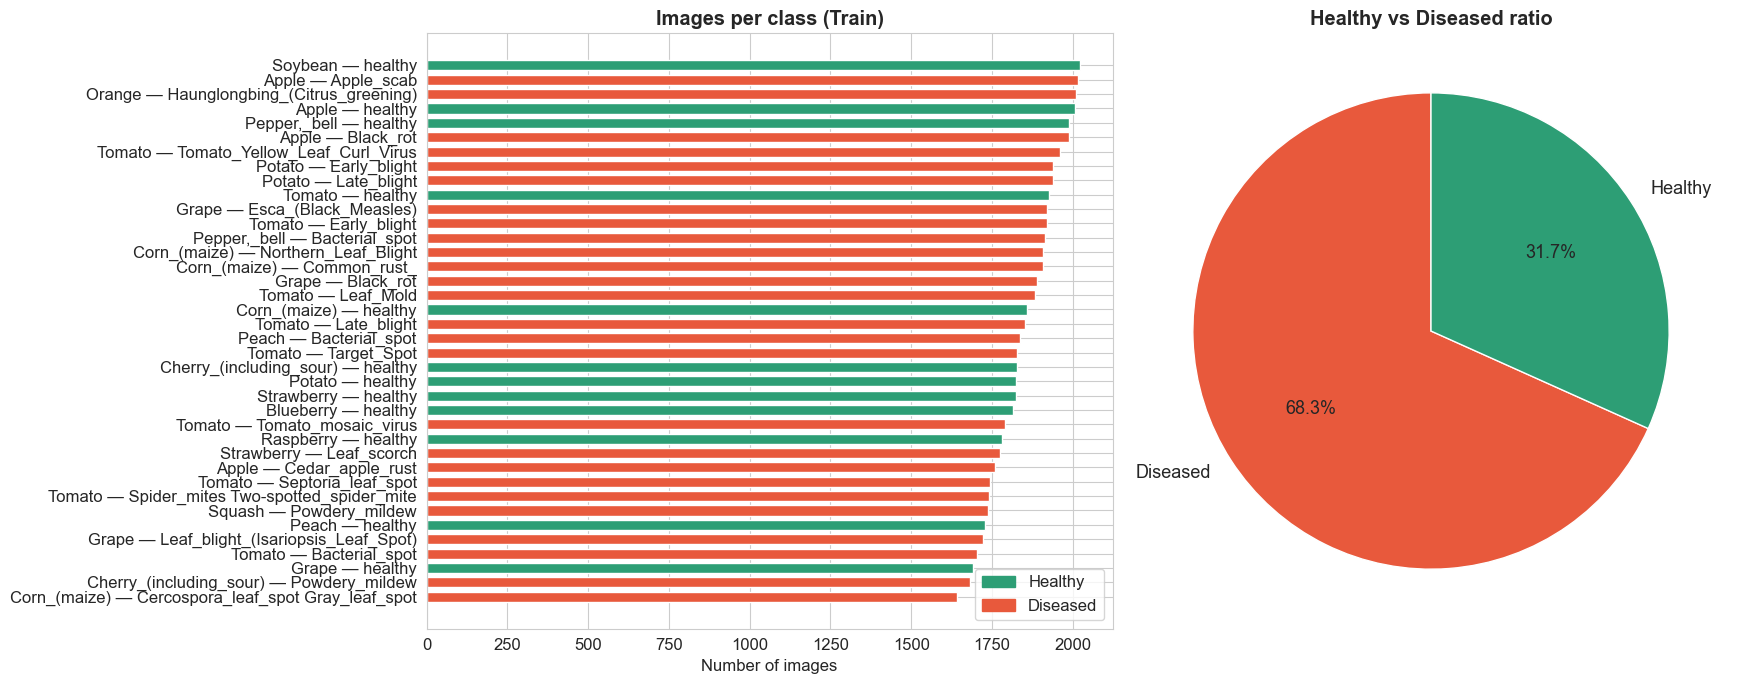


Healthy images  : 22,294 (31.7%)
Diseased images : 48,001 (68.3%)

Min per class   : 1,642
Max per class   : 2,022
Mean per class  : 1850


In [3]:
# Распределение классов
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: кол-во изображений по классам ---
class_counts = df_train["class"].value_counts()
colors = ["#2d9e75" if "healthy" in c.lower() else "#e8593c"
          for c in class_counts.index]

axes[0].barh(
    [c.replace("___", " — ") for c in class_counts.index],
    class_counts.values,
    color=colors, height=0.7
)
axes[0].set_xlabel("Number of images")
axes[0].set_title("Images per class (Train)", fontweight="bold")
axes[0].invert_yaxis()

healthy_patch = mpatches.Patch(color="#2d9e75", label="Healthy")
disease_patch = mpatches.Patch(color="#e8593c", label="Diseased")
axes[0].legend(handles=[healthy_patch, disease_patch])

# --- Right: Healthy vs Diseased pie ---
healthy_count  = df_train["is_healthy"].sum()
diseased_count = len(df_train) - healthy_count

axes[1].pie(
    [diseased_count, healthy_count],
    labels=["Diseased", "Healthy"],
    colors=["#e8593c", "#2d9e75"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 13}
)
axes[1].set_title("Healthy vs Diseased ratio", fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nHealthy images  : {healthy_count:,} ({100*healthy_count/len(df_train):.1f}%)")
print(f"Diseased images : {diseased_count:,} ({100*diseased_count/len(df_train):.1f}%)")
print(f"\nMin per class   : {class_counts.min():,}")
print(f"Max per class   : {class_counts.max():,}")
print(f"Mean per class  : {class_counts.mean():.0f}")

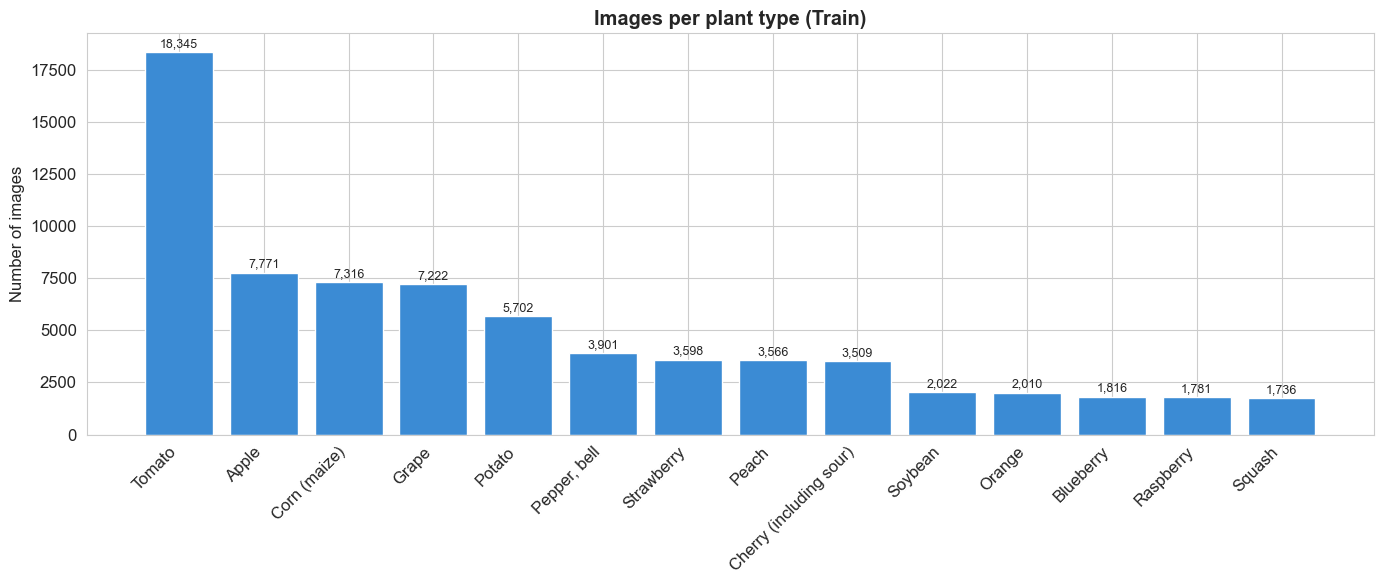


Plants in dataset:
  Tomato                              18,345 images | 10 classes
  Apple                                7,771 images | 4 classes
  Corn (maize)                         7,316 images | 4 classes
  Grape                                7,222 images | 4 classes
  Potato                               5,702 images | 3 classes
  Pepper, bell                         3,901 images | 2 classes
  Strawberry                           3,598 images | 2 classes
  Peach                                3,566 images | 2 classes
  Cherry (including sour)              3,509 images | 2 classes
  Soybean                              2,022 images | 1 classes
  Orange                               2,010 images | 1 classes
  Blueberry                            1,816 images | 1 classes
  Raspberry                            1,781 images | 1 classes
  Squash                               1,736 images | 1 classes


In [4]:
# Распределение по растениям
plant_counts = df_train.groupby("plant").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plant_counts.index, plant_counts.values, color="#3b8bd4", edgecolor="white")

# Подписи на барах
for bar, val in zip(bars, plant_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}", ha="center", va="bottom", fontsize=9)

ax.set_title("Images per plant type (Train)", fontweight="bold")
ax.set_ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_plant_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPlants in dataset:")
for plant, count in plant_counts.items():
    n_diseases = df_train[df_train["plant"] == plant]["class"].nunique()
    print(f"  {plant:<35} {count:>6,} images | {n_diseases} classes")

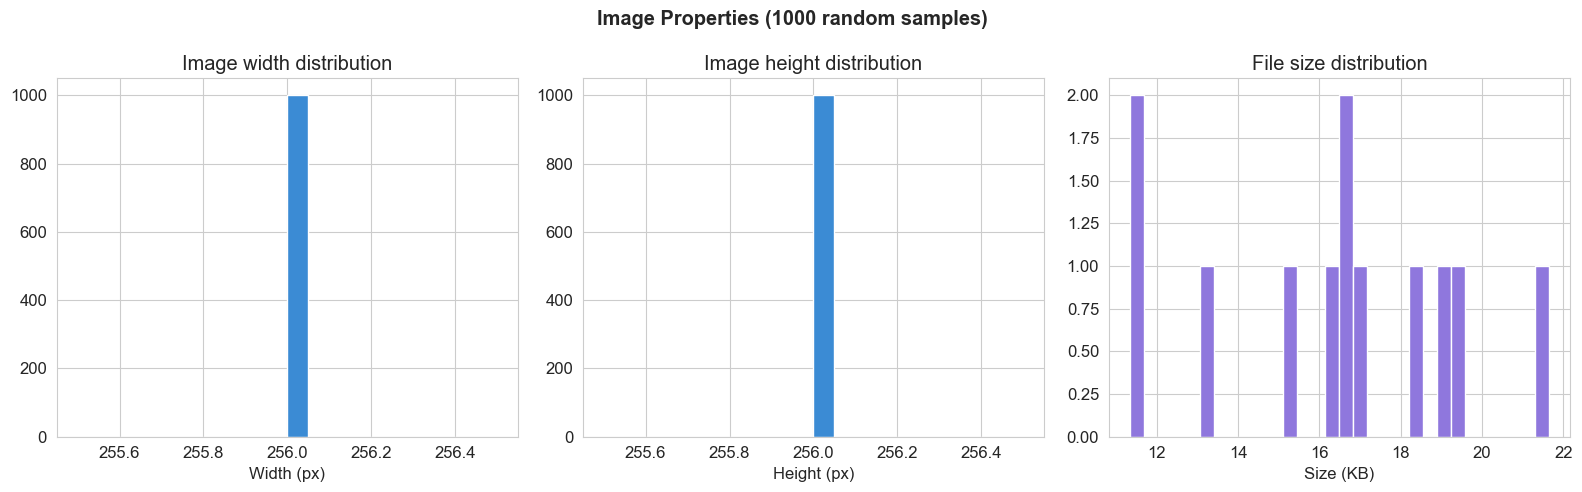

Width  : 256px ± 0px
Height : 256px ± 0px
Size   : 16.4KB ± 3.1KB


In [5]:
# Анализ размеров изображений

def get_image_size(path: str):
    try:
        with Image.open(path) as img:
            return img.size  # (width, height)
    except Exception:
        return None, None

# Сэмплируем 1000 изображений
sample = df_train.sample(n=1000, random_state=42)
sizes  = sample["path"].apply(lambda p: pd.Series(get_image_size(p),
                                                    index=["width", "height"]))
sample = pd.concat([sample.reset_index(drop=True), sizes], axis=1)
sample = sample.dropna(subset=["width", "height"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Width
axes[0].hist(sample["width"], bins=20, color="#3b8bd4", edgecolor="white")
axes[0].set_title("Image width distribution")
axes[0].set_xlabel("Width (px)")

# Height
axes[1].hist(sample["height"], bins=20, color="#3b8bd4", edgecolor="white")
axes[1].set_title("Image height distribution")
axes[1].set_xlabel("Height (px)")

# File size
axes[2].hist(sample["size_kb"], bins=30, color="#8f77dd", edgecolor="white")
axes[2].set_title("File size distribution")
axes[2].set_xlabel("Size (KB)")

plt.suptitle("Image Properties (1000 random samples)", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_image_properties.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Width  : {sample['width'].mean():.0f}px ± {sample['width'].std():.0f}px")
print(f"Height : {sample['height'].mean():.0f}px ± {sample['height'].std():.0f}px")
print(f"Size   : {sample['size_kb'].mean():.1f}KB ± {sample['size_kb'].std():.1f}KB")

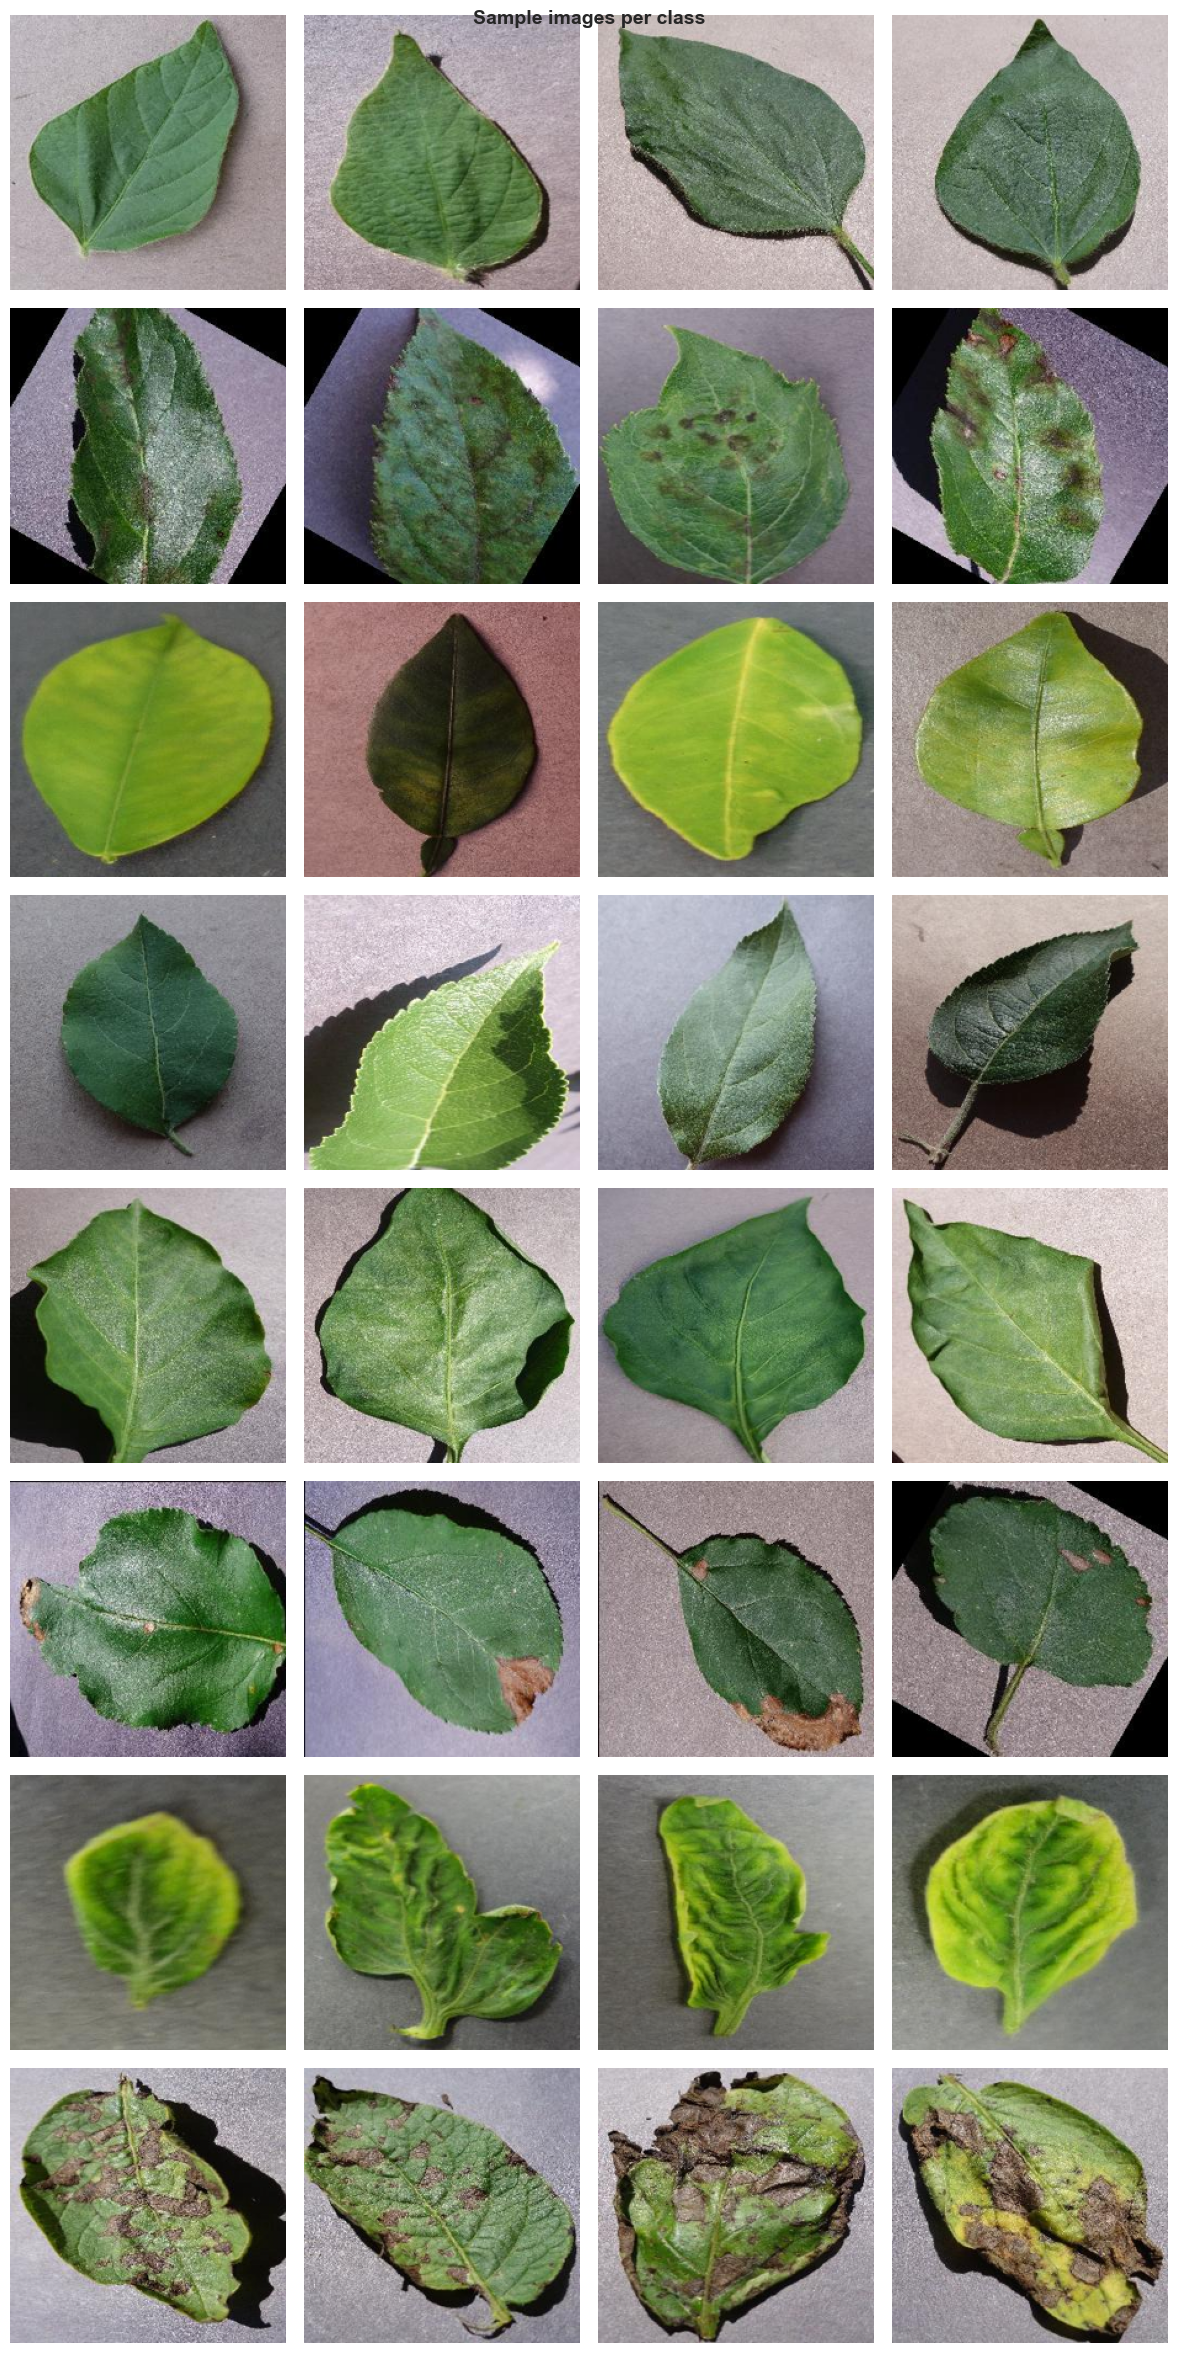

In [6]:
# Примеры изображений по классам
def show_sample_images(df: pd.DataFrame, n_classes: int = 8, n_per_class: int = 4):
    classes = df["class"].value_counts().head(n_classes).index.tolist()
    fig, axes = plt.subplots(n_classes, n_per_class,
                              figsize=(n_per_class * 3, n_classes * 3))

    for row_idx, cls in enumerate(classes):
        samples = df[df["class"] == cls].sample(
            n=min(n_per_class, len(df[df["class"] == cls])),
            random_state=42
        )
        for col_idx, (_, row) in enumerate(samples.iterrows()):
            ax = axes[row_idx, col_idx]
            try:
                img = Image.open(row["path"]).resize((224, 224))
                ax.imshow(img)
            except Exception:
                ax.set_facecolor("#ddd")
            ax.axis("off")
            if col_idx == 0:
                label = cls.replace("___", "\n").replace("_", " ")
                ax.set_ylabel(label, fontsize=8, rotation=0,
                              ha="right", va="center", labelpad=60)

    plt.suptitle("Sample images per class", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "04_sample_images.png", dpi=100, bbox_inches="tight")
    plt.show()

show_sample_images(df_train)

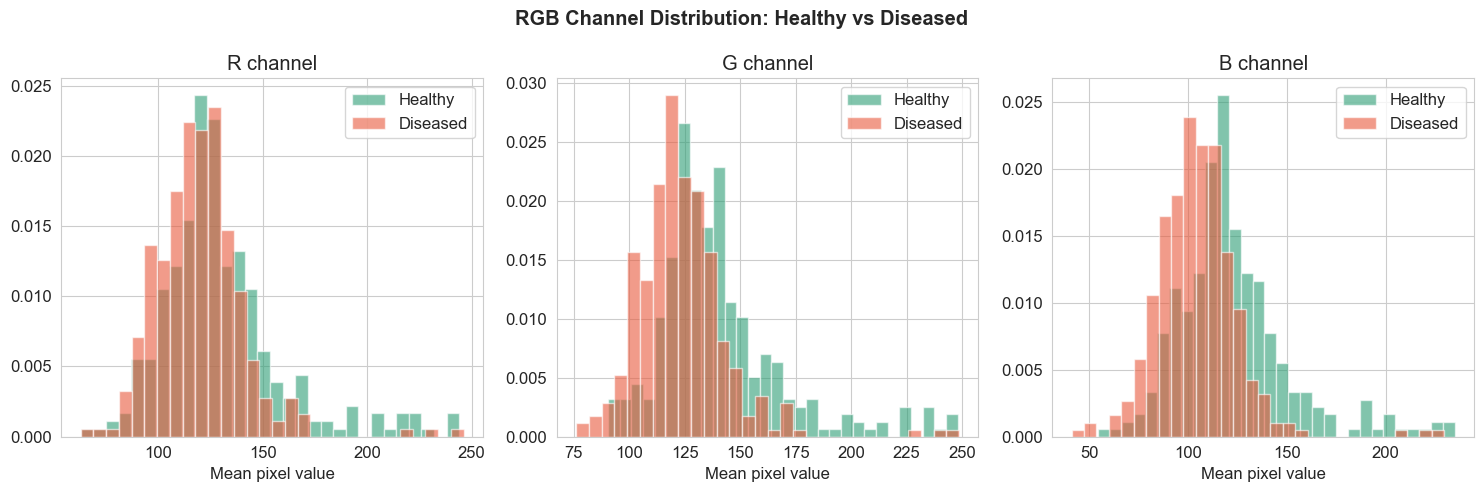

In [7]:
# RGB анализ (healthy vs diseased)
def get_rgb_stats(path: str):
    try:
        img = np.array(Image.open(path).convert("RGB").resize((64, 64)))
        return img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()
    except Exception:
        return None, None, None

# Сэмплируем по 300 healthy и 300 diseased
healthy_sample  = df_train[df_train["is_healthy"]].sample(300, random_state=42)
diseased_sample = df_train[~df_train["is_healthy"]].sample(300, random_state=42)

for df_s, label in [(healthy_sample, "healthy"), (diseased_sample, "diseased")]:
    rgb = df_s["path"].apply(lambda p: pd.Series(
        get_rgb_stats(p), index=["R", "G", "B"]
    ))
    df_s = pd.concat([df_s.reset_index(drop=True), rgb], axis=1)
    globals()[f"rgb_{label}"] = df_s

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ["R", "G", "B"]
colors   = ["#e24b4a", "#63992a", "#378add"]

for ax, ch, col in zip(axes, channels, colors):
    ax.hist(rgb_healthy[ch].dropna(),  bins=30, alpha=0.6,
            color="#2d9e75", label="Healthy",  density=True)
    ax.hist(rgb_diseased[ch].dropna(), bins=30, alpha=0.6,
            color="#e8593c", label="Diseased", density=True)
    ax.set_title(f"{ch} channel")
    ax.set_xlabel("Mean pixel value")
    ax.legend()

plt.suptitle("RGB Channel Distribution: Healthy vs Diseased",
             fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_rgb_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
random.seed(42)

VALID_DIR = DATA_ROOT / "valid"
TEST_DIR  = DATA_ROOT / "test"

# Удаляем старый test (там было 33 рандомных фото)
if TEST_DIR.exists():
    shutil.rmtree(TEST_DIR)
TEST_DIR.mkdir()

# Берём 10% из valid → переносим в test
moved_total = 0

for class_dir in sorted(VALID_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    images  = sorted(class_dir.iterdir())
    n_test  = max(1, int(len(images) * 0.10))  # 10% каждого класса
    to_move = random.sample(images, n_test)

    # Создаём папку класса в test
    test_class_dir = TEST_DIR / class_dir.name
    test_class_dir.mkdir(exist_ok=True)

    # Копируем (не перемещаем — оставляем valid нетронутым)
    for img in to_move:
        shutil.copy2(str(img), str(test_class_dir / img.name))

    moved_total += n_test

print(f"✅ Test split создан!")
print(f"   Классов : 38")
print(f"   Изображений : {moved_total:,}")

# Пересчитываем
df_test_new = scan_dataset(TEST_DIR)
print(f"\n📊 Новый размер:")
print(f"   Valid : {len(df_valid):,} images (осталось)")
print(f"   Test  : {len(df_test_new):,} images (новый)")

✅ Test split создан!
   Классов : 38
   Изображений : 1,742

📊 Новый размер:
   Valid : 17,572 images (осталось)
   Test  : 1,742 images (новый)


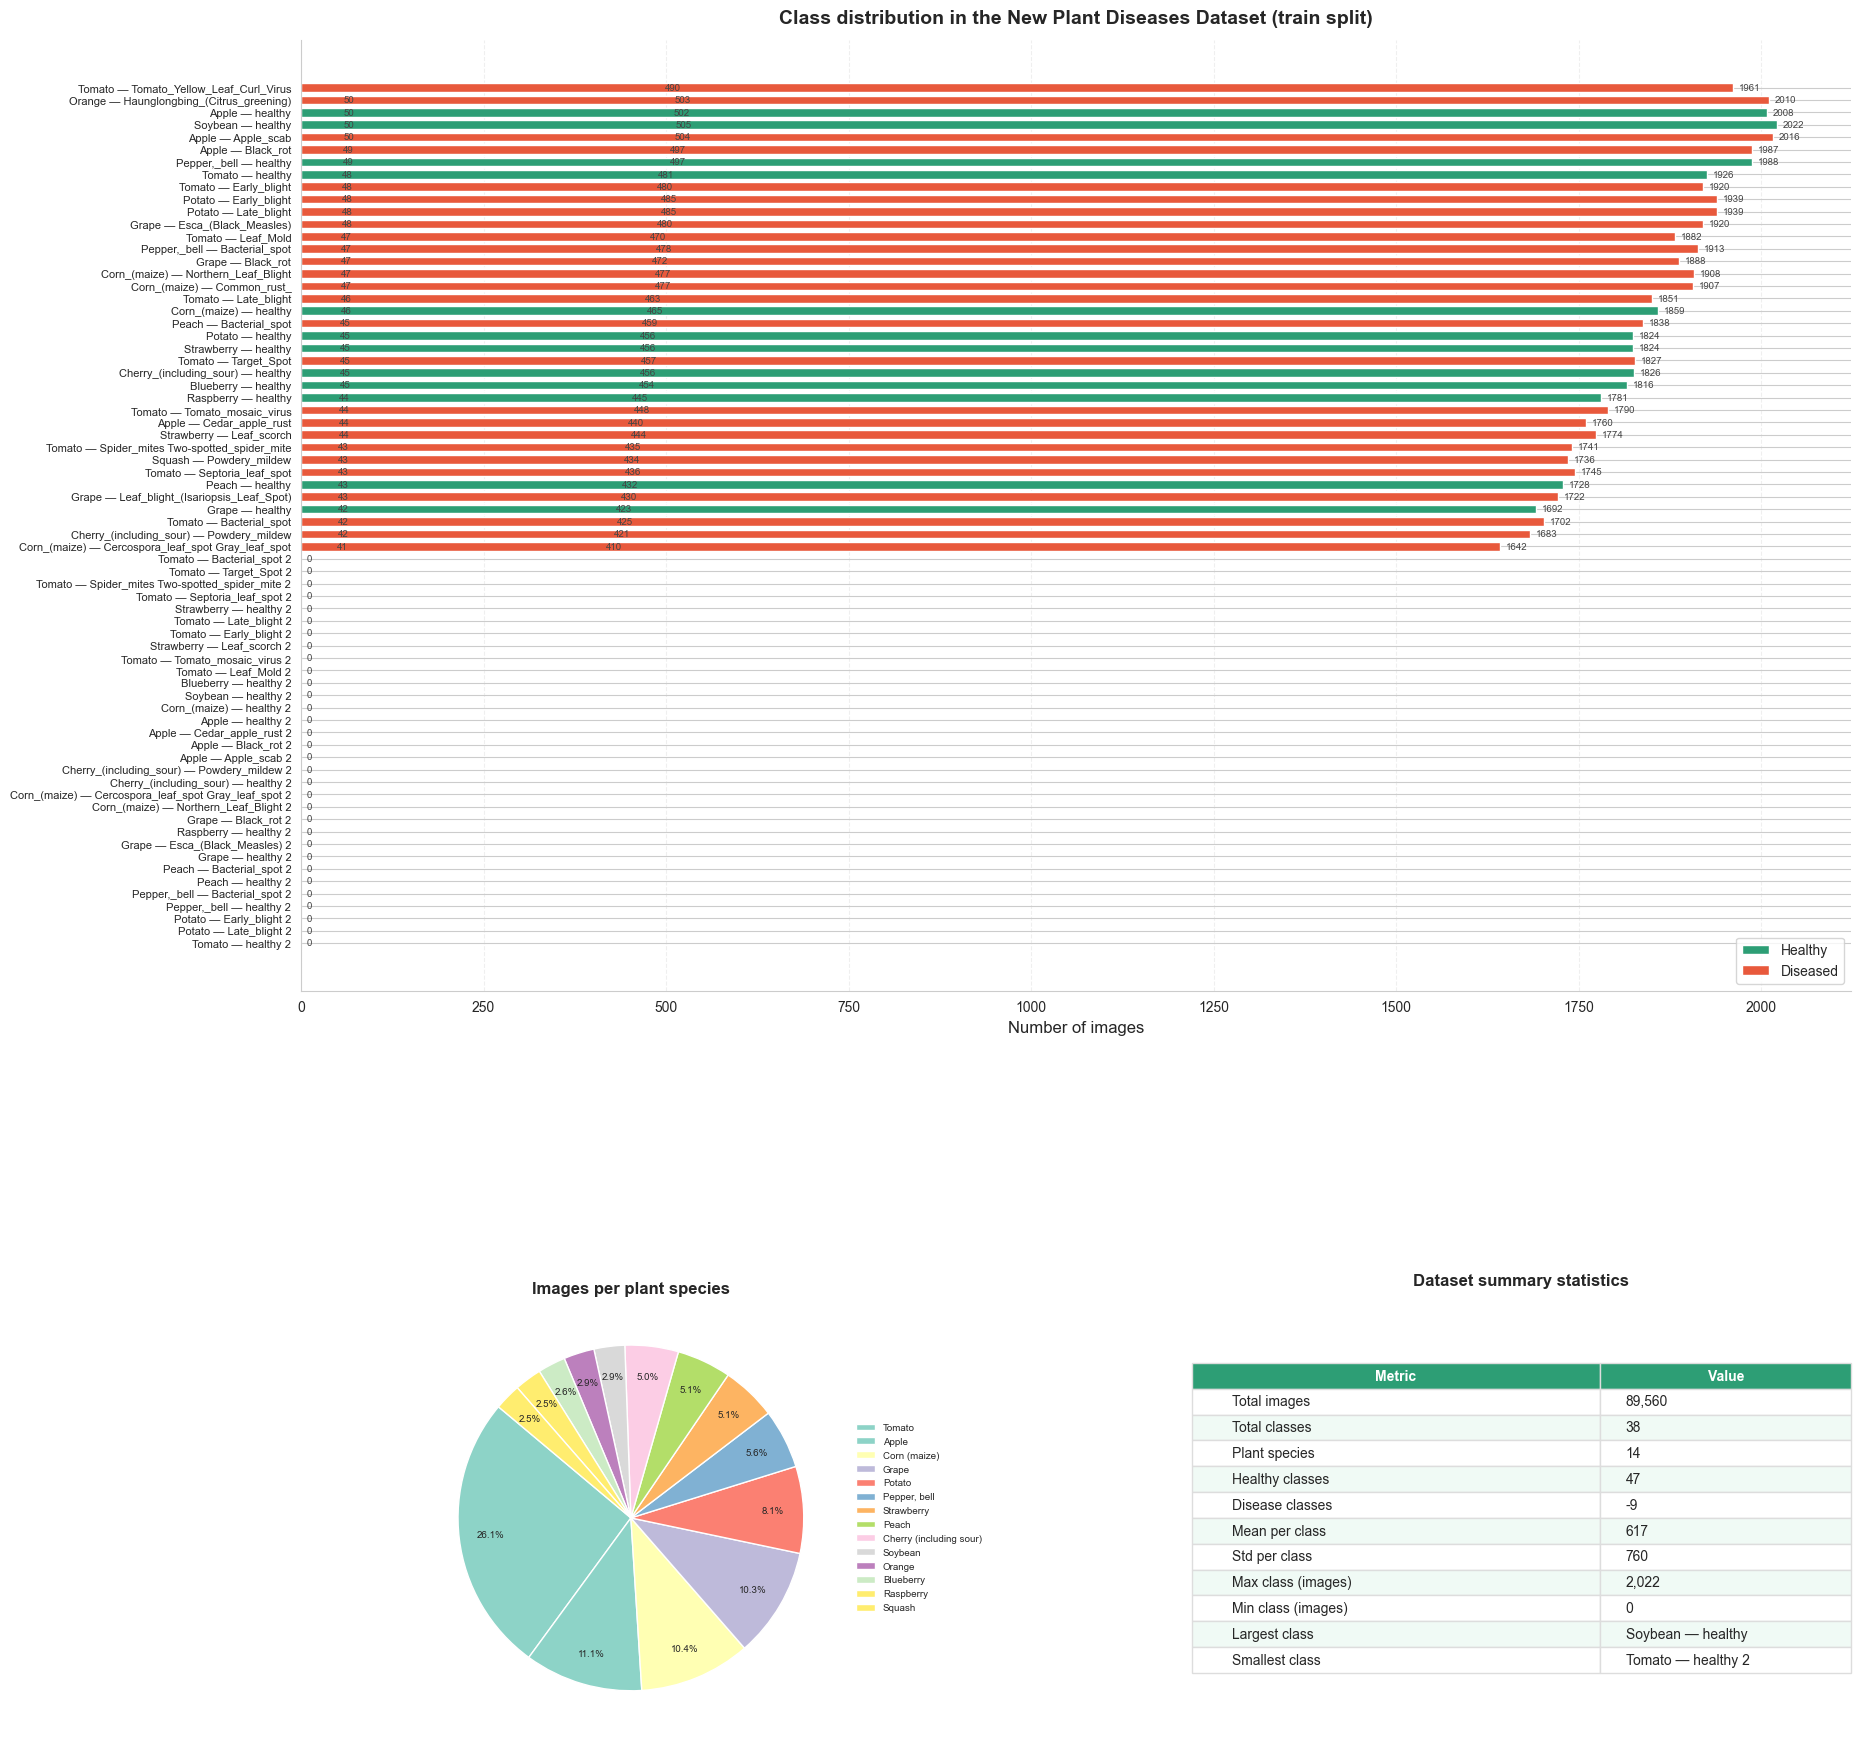

Saved → notebooks/plots/dataset_describe.png


In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image


Train = DATA_ROOT / "train"
Valid = DATA_ROOT / 'valid'
Test = DATA_ROOT / 'test'
SAVE_PATH = Path("notebooks/plots/dataset_describe.png")


records = []
for class_dir in sorted(Train.iterdir()):
    if not class_dir.is_dir():
        continue
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))
    plant, disease = class_dir.name.split("___") if "___" in class_dir.name else (class_dir.name, "unknown")
    plant = plant.replace("_", " ")
    disease = disease.replace("_", " ")
    records.append({
        "class": class_dir.name,
        "plant": plant,
        "disease": disease,
        "count": len(images),
        "is_healthy": "healthy" in class_dir.name.lower()
    })

    records_2 = []
for class_dir in sorted(Valid.iterdir()):
    if not class_dir.is_dir():
        continue
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))
    plant, disease = class_dir.name.split("___") if "___" in class_dir.name else (class_dir.name, "unknown")
    plant = plant.replace("_", " ")
    disease = disease.replace("_", " ")
    records_2.append({
        "class": class_dir.name,
        "plant": plant,
        "disease": disease,
        "count": len(images),
        "is_healthy": "healthy" in class_dir.name.lower()
    })

    records_3 = []
for class_dir in sorted(Test.iterdir()):
    if not class_dir.is_dir():
        continue
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))
    plant, disease = class_dir.name.split("___") if "___" in class_dir.name else (class_dir.name, "unknown")
    plant = plant.replace("_", " ")
    disease = disease.replace("_", " ")
    records_3.append({
        "class": class_dir.name,
        "plant": plant,
        "disease": disease,
        "count": len(images),
        "is_healthy": "healthy" in class_dir.name.lower()
    })


records_ = records + records_2 + records_3
df = pd.DataFrame(records_).sort_values("count", ascending=True)

# ── ЦВЕТА ─────────────────────────────────────────────────
colors = ["#2d9e75" if h else "#e8593c" for h in df["is_healthy"]]

# ── ФИГУРА ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22), facecolor="white")
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.45, wspace=0.35,
                        height_ratios=[2.2, 1])

# ── PLOT 1: горизонтальный bar chart всех классов ─────────
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(df["class"].str.replace("___", " — "),
                df["count"], color=colors, height=0.7)

ax1.set_xlabel("Number of images", fontsize=12)
ax1.set_title("Class distribution in the New Plant Diseases Dataset (train split)",
              fontsize=14, fontweight="bold", pad=12)
ax1.tick_params(axis="y", labelsize=8)
ax1.tick_params(axis="x", labelsize=10)
ax1.grid(axis="x", alpha=0.3, linestyle="--")
ax1.spines[["top","right"]].set_visible(False)

# значения на барах
for bar in bars:
    w = bar.get_width()
    ax1.text(w + 8, bar.get_y() + bar.get_height()/2,
             str(int(w)), va="center", ha="left", fontsize=7, color="#444")

# легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2d9e75", label="Healthy"),
                   Patch(facecolor="#e8593c", label="Diseased")]
ax1.legend(handles=legend_elements, loc="lower right", fontsize=10)

# ── PLOT 2: по растениям (plant distribution) ─────────────
ax2 = fig.add_subplot(gs[1, 0])
plant_counts = df.groupby("plant")["count"].sum().sort_values(ascending=False)
plant_colors = plt.cm.Set3(np.linspace(0, 1, len(plant_counts)))
wedges, texts, autotexts = ax2.pie(
    plant_counts,
    labels=None,
    autopct="%1.1f%%",
    colors=plant_colors,
    pctdistance=0.82,
    startangle=140
)
for t in autotexts:
    t.set_fontsize(7)
ax2.set_title("Images per plant species", fontsize=12, fontweight="bold")
ax2.legend(wedges, plant_counts.index,
           loc="center left", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False)

# ── PLOT 3: summary stats таблица ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis("off")

total_images   = df["count"].sum()
total_classes  = 38
total_plants   = df["plant"].nunique()
healthy_cls    = df["is_healthy"].sum()
diseased_cls   = total_classes - healthy_cls
max_class      = df.loc[df["count"].idxmax(), "class"].replace("___", " — ")
min_class      = df.loc[df["count"].idxmin(), "class"].replace("___", " — ")
mean_per_class = int(df["count"].mean())
std_per_class  = int(df["count"].std())

table_data = [
    ["Total images",         f"{total_images:,}"],
    ["Total classes",        str(total_classes)],
    ["Plant species",        str(total_plants)],
    ["Healthy classes",      str(healthy_cls)],
    ["Disease classes",      str(diseased_cls)],
    ["Mean per class",       f"{mean_per_class:,}"],
    ["Std per class",        f"{std_per_class:,}"],
    ["Max class (images)",   f"{df['count'].max():,}"],
    ["Min class (images)",   f"{df['count'].min():,}"],
    ["Largest class",        max_class[:30]],
    ["Smallest class",       min_class[:30]],
]

tbl = ax3.table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    loc="center",
    cellLoc="left",
    colWidths=[0.62, 0.38]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.55)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#dddddd")
    if row == 0:
        cell.set_facecolor("#2d9e75")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f0faf5")
    else:
        cell.set_facecolor("white")

ax3.set_title("Dataset summary statistics", fontsize=12,
              fontweight="bold", pad=12)

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")

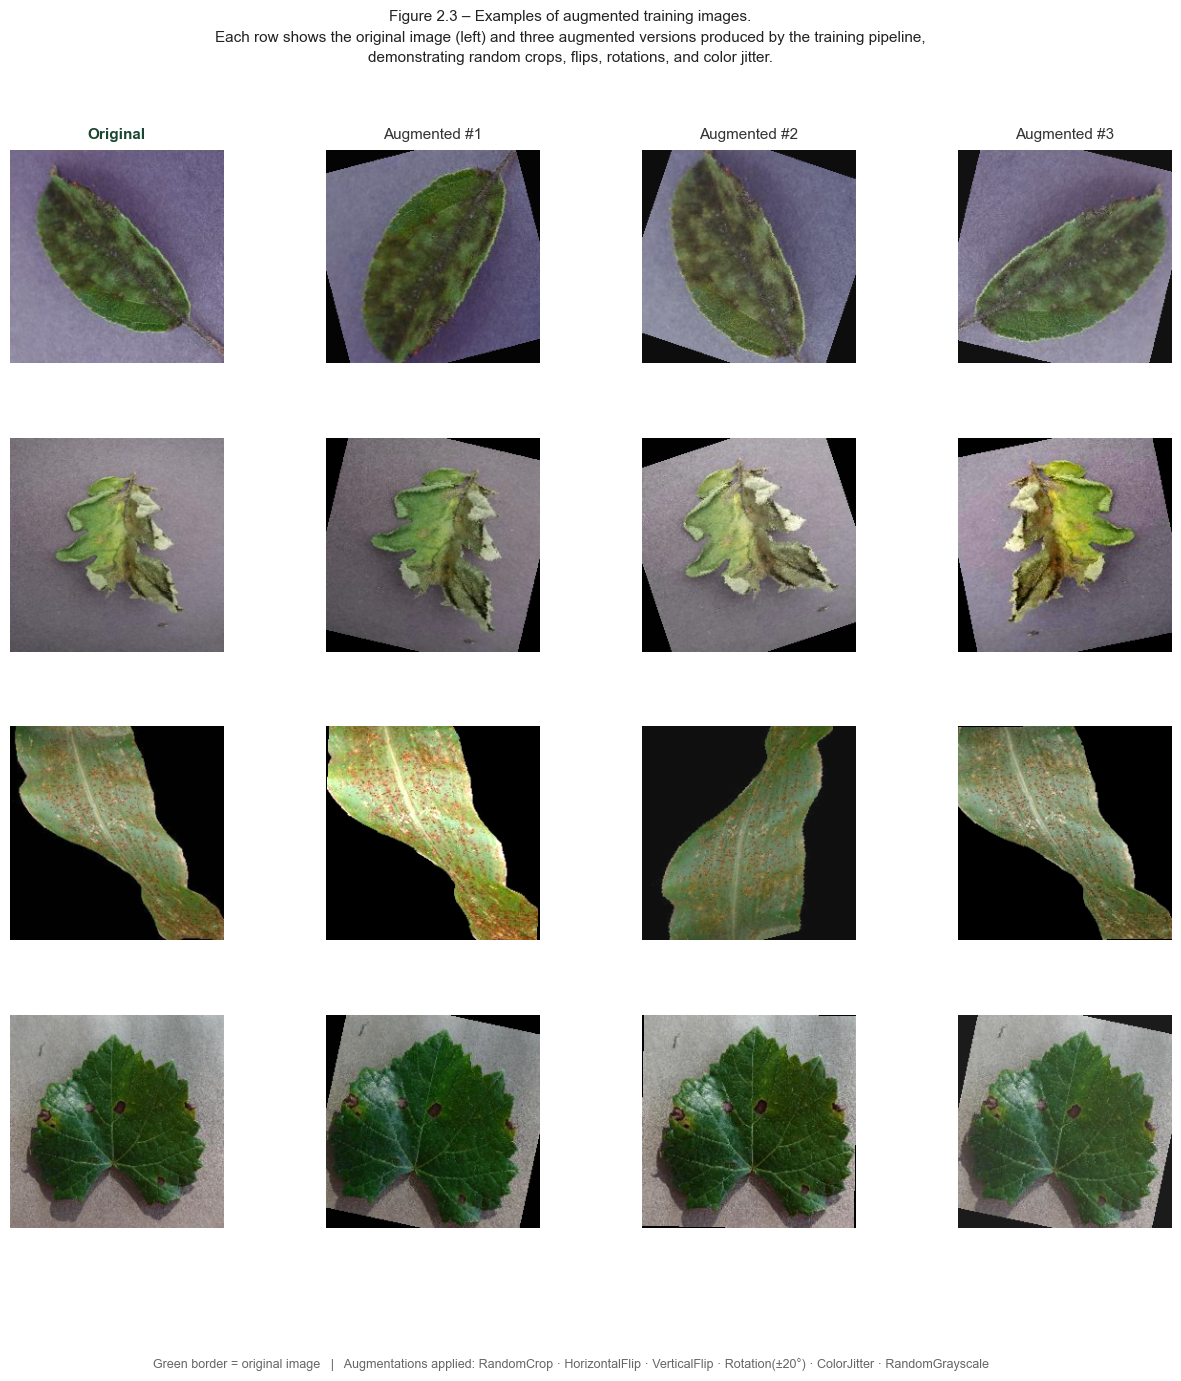

Saved → notebooks/plots/preprocessing_test.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
import torch
from torchvision import transforms
import random

# ── CONFIG ────────────────────────────────────────────────
DATA_DIR  = Path("data/raw/train")
SAVE_PATH = Path("notebooks/plots/preprocessing_test.png")

# ── AUGMENTATION PIPELINE (точно как в src/preprocessing.py) ──
train_transform = transforms.Compose([
    transforms.Resize((248, 248)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),
])

# без аугментации — для оригинала
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# ── ВЫБИРАЕМ 4 РАЗНЫХ КЛАССА ──────────────────────────────
sample_classes = [
    "Apple___Apple_scab",
    "Tomato___Late_blight",
    "Corn_(maize)___Common_rust_",
    "Grape___Black_rot",
]

def get_random_image(class_name):
    class_dir = Train / class_name
    images = list(class_dir.glob("*.jpg")) + \
             list(class_dir.glob("*.JPG")) + \
             list(class_dir.glob("*.png"))
    return Image.open(random.choice(images)).convert("RGB")

# ── FIGURE ────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), facecolor="white")
gs  = gridspec.GridSpec(
    4, 4, figure=fig,
    hspace=0.35, wspace=0.08
)

col_titles = ["Original", "Augmented #1", "Augmented #2", "Augmented #3"]
row_labels = [
    "Apple Scab",
    "Tomato Late Blight",
    "Corn Common Rust",
    "Grape Black Rot",
]

for row_idx, class_name in enumerate(sample_classes):
    img = get_random_image(class_name)

    for col_idx in range(4):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        if col_idx == 0:
            # оригинал
            display_img = base_transform(img)
        else:
            # аугментированная версия
            display_img = train_transform(img)

        ax.imshow(display_img)
        ax.axis("off")

        # заголовки колонок (только первая строка)
        if row_idx == 0:
            ax.set_title(
                col_titles[col_idx],
                fontsize=11,
                fontweight="bold" if col_idx == 0 else "normal",
                color="#1a4731" if col_idx == 0 else "#333333",
                pad=8
            )

        # подписи строк (только первая колонка)
        if col_idx == 0:
            ax.set_ylabel(
                row_labels[row_idx],
                fontsize=10,
                fontweight="bold",
                color="#333333",
                labelpad=8
            )

        # рамка вокруг оригинала
        if col_idx == 0:
            for spine in ax.spines.values():
                spine.set_edgecolor("#2d9e75")
                spine.set_linewidth(2)
                spine.set_visible(True)

# общий заголовок
fig.suptitle(
    "Figure 2.3 – Examples of augmented training images.\n"
    "Each row shows the original image (left) and three augmented versions produced by the training pipeline,\n"
    "demonstrating random crops, flips, rotations, and color jitter.",
    fontsize=11,
    y=0.98,
    linespacing=1.6,
    color="#222222"
)

# подпись внизу
fig.text(
    0.5, 0.01,
    "Green border = original image   |   "
    "Augmentations applied: RandomCrop · HorizontalFlip · VerticalFlip · "
    "Rotation(±20°) · ColorJitter · RandomGrayscale",
    ha="center", fontsize=9, color="#666666"
)

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(
    SAVE_PATH, dpi=180,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
plt.show()
print(f"Saved → {SAVE_PATH}")

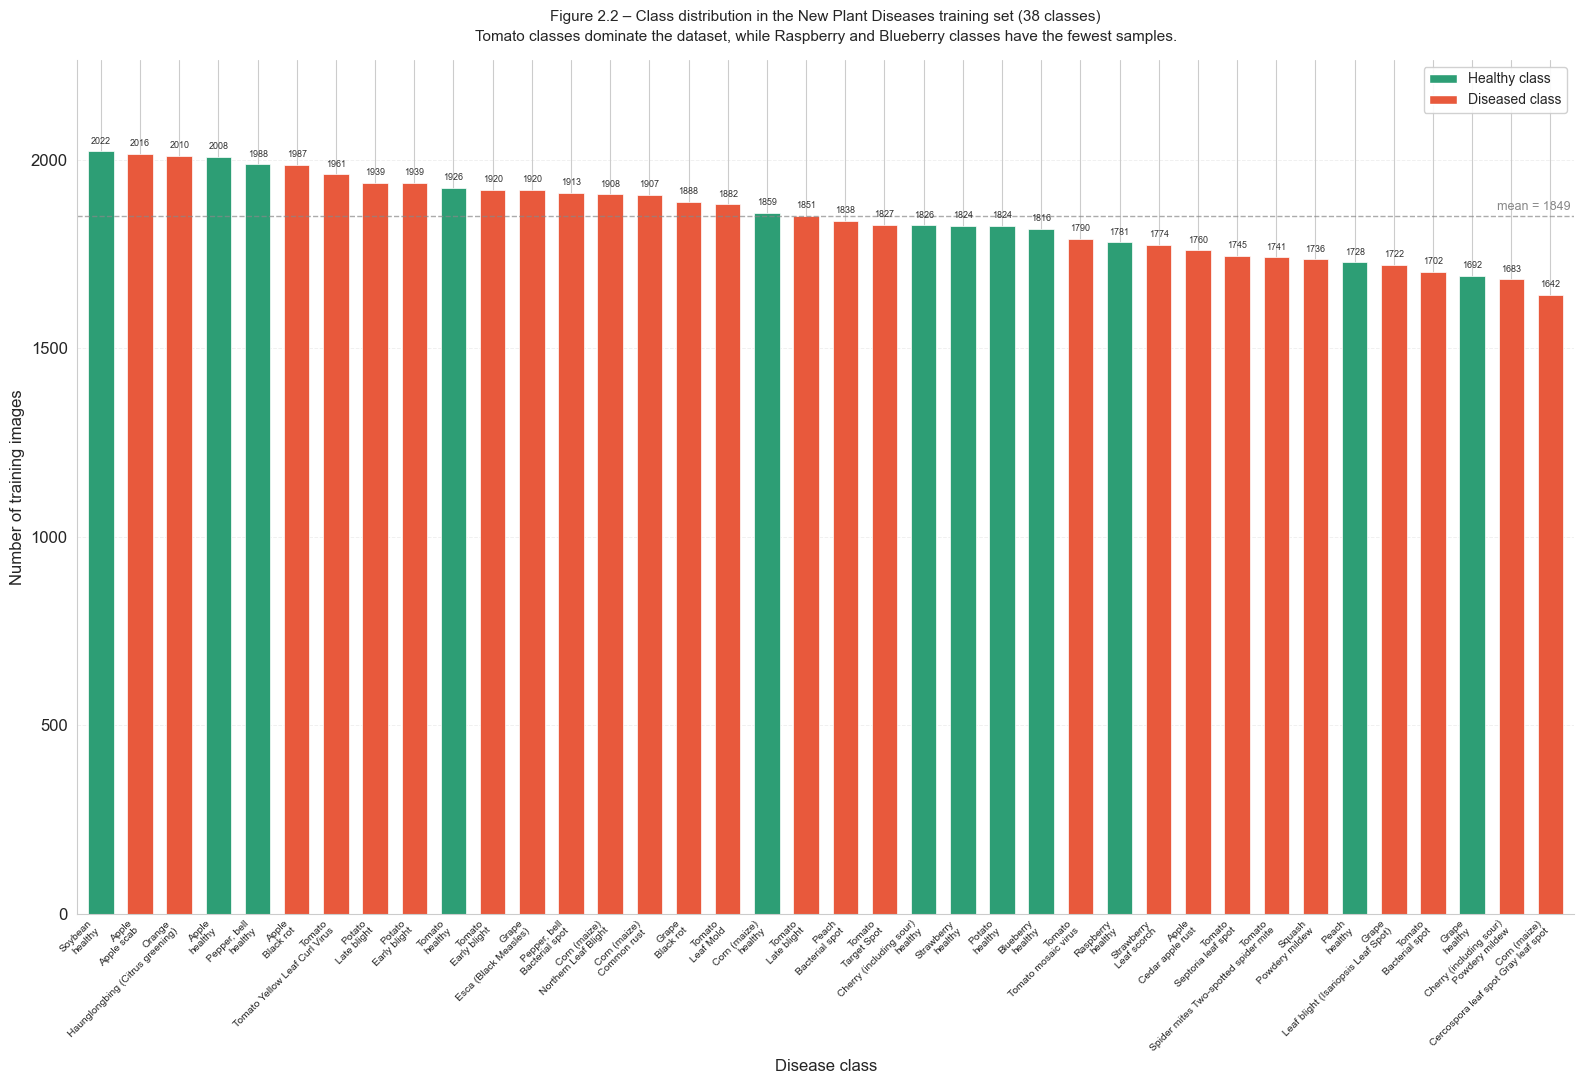

Saved → notebooks/plots/01_class_distribution.png


In [12]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────
SAVE_PATH = Path("notebooks/plots/01_class_distribution.png")

# ── СОБИРАЕМ ДАННЫЕ ───────────────────────────────────────
classes, counts, colors = [], [], []

for class_dir in sorted(Train.iterdir()):
    if not class_dir.is_dir():
        continue
    images = list(class_dir.glob("*.jpg")) + \
             list(class_dir.glob("*.JPG")) + \
             list(class_dir.glob("*.png"))
    
    name = class_dir.name.replace("___", "\n").replace("_", " ")
    is_healthy = "healthy" in class_dir.name.lower()
    
    classes.append(name)
    counts.append(len(images))
    colors.append("#2d9e75" if is_healthy else "#e8593c")

# сортируем по убыванию
paired = sorted(zip(counts, classes, colors), reverse=True)
counts, classes, colors = zip(*paired)

# ── FIGURE ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11), facecolor="white")

bars = ax.bar(range(len(classes)), counts,
              color=colors, width=0.65, edgecolor="white", linewidth=0.5)

# подписи значений над барами
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            str(count),
            ha="center", va="bottom",
            fontsize=6.5, color="#333333")

# оси
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right",
                   fontsize=7.5, linespacing=1.1)
ax.set_ylabel("Number of training images", fontsize=12)
ax.set_xlabel("Disease class", fontsize=12)
ax.set_title(
    "Figure 2.2 – Class distribution in the New Plant Diseases training set (38 classes)\n"
    "Tomato classes dominate the dataset, while Raspberry and Blueberry classes have the fewest samples.",
    fontsize=11, pad=14, linespacing=1.5
)

ax.set_xlim(-0.6, len(classes) - 0.4)
ax.set_ylim(0, max(counts) * 1.12)
ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0)

# легенда
legend = [
    mpatches.Patch(facecolor="#2d9e75", label="Healthy class"),
    mpatches.Patch(facecolor="#e8593c", label="Diseased class"),
]
ax.legend(handles=legend, fontsize=10,
          loc="upper right", frameon=True, framealpha=0.9)

# среднее значение — пунктирная линия
mean_val = sum(counts) / len(counts)
ax.axhline(mean_val, color="#888888", linestyle="--",
           linewidth=1, alpha=0.7)
ax.text(len(classes) - 0.5, mean_val + 10,
        f"mean = {int(mean_val)}",
        ha="right", va="bottom",
        fontsize=9, color="#888888")

plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")

/var/folders/dz/x3s0t03n281bp8220mmy0kvh0000gn/T/ipykernel_43738/76340408.py:119: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dz/x3s0t03n281bp8220mmy0kvh0000gn/T/ipykernel_43738/76340408.py:123: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(SAVE_PATH, dpi=180,
/Users/shopangaliy/Documents/Doc/IT3-2208/4 course/2_semester/DeepLearning_Ai/PlantGuard_AI /venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


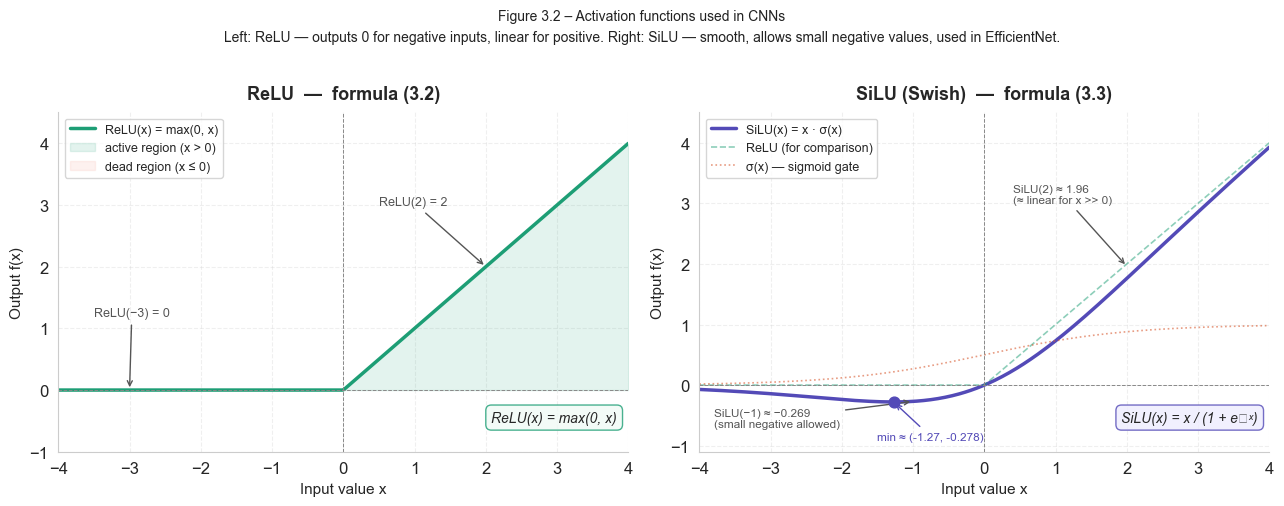

Saved → notebooks/plots/activation_functions.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

SAVE_PATH = Path("notebooks/plots/activation_functions.png")

x = np.linspace(-4, 4, 400)

# ReLU
relu = np.maximum(0, x)

# SiLU / Swish
silu = x / (1 + np.exp(-x))

# Sigmoid (для справки)
sigmoid = 1 / (1 + np.exp(-x))

# ── FIGURE ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")

# ── PLOT 1: ReLU ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(x, relu, color="#1D9E75", linewidth=2.5, label="ReLU(x) = max(0, x)")
ax1.axhline(0, color="#888888", linewidth=0.7, linestyle="--")
ax1.axvline(0, color="#888888", linewidth=0.7, linestyle="--")

# аннотации ключевых точек
ax1.annotate("ReLU(−3) = 0",
             xy=(-3, 0), xytext=(-3.5, 1.2),
             arrowprops=dict(arrowstyle="->", color="#555"),
             fontsize=9, color="#555")
ax1.annotate("ReLU(2) = 2",
             xy=(2, 2), xytext=(0.5, 3.0),
             arrowprops=dict(arrowstyle="->", color="#555"),
             fontsize=9, color="#555")

ax1.fill_between(x, relu, 0,
                 where=(x >= 0), alpha=0.12,
                 color="#1D9E75", label="active region (x > 0)")
ax1.fill_between(x, relu, 0,
                 where=(x < 0), alpha=0.08,
                 color="#e8593c", label="dead region (x ≤ 0)")

ax1.set_xlim(-4, 4)
ax1.set_ylim(-1, 4.5)
ax1.set_xlabel("Input value x", fontsize=11)
ax1.set_ylabel("Output f(x)", fontsize=11)
ax1.set_title("ReLU  —  formula (3.2)", fontsize=13, fontweight="bold", pad=10)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.3, linestyle="--")
ax1.spines[["top", "right"]].set_visible(False)

# формула
ax1.text(0.98, 0.08,
         "ReLU(x) = max(0, x)",
         transform=ax1.transAxes,
         ha="right", va="bottom",
         fontsize=10, style="italic",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="#f0faf5", edgecolor="#1D9E75", alpha=0.8))

# ── PLOT 2: SiLU ──────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x, silu,    color="#534AB7", linewidth=2.5, label="SiLU(x) = x · σ(x)")
ax2.plot(x, relu,    color="#1D9E75", linewidth=1.2,
         linestyle="--", alpha=0.5, label="ReLU (for comparison)")
ax2.plot(x, sigmoid, color="#D85A30", linewidth=1.2,
         linestyle=":", alpha=0.6, label="σ(x) — sigmoid gate")

ax2.axhline(0, color="#888888", linewidth=0.7, linestyle="--")
ax2.axvline(0, color="#888888", linewidth=0.7, linestyle="--")

# аннотации
ax2.annotate("SiLU(−1) ≈ −0.269\n(small negative allowed)",
             xy=(-1, -0.269), xytext=(-3.8, -0.7),
             arrowprops=dict(arrowstyle="->", color="#555"),
             fontsize=8.5, color="#555")
ax2.annotate("SiLU(2) ≈ 1.96\n(≈ linear for x >> 0)",
             xy=(2, 1.96), xytext=(0.4, 3.0),
             arrowprops=dict(arrowstyle="->", color="#555"),
             fontsize=8.5, color="#555")

# минимум SiLU
min_idx = np.argmin(silu)
ax2.scatter(x[min_idx], silu[min_idx],
            color="#534AB7", s=60, zorder=5)
ax2.annotate(f"min ≈ ({x[min_idx]:.2f}, {silu[min_idx]:.3f})",
             xy=(x[min_idx], silu[min_idx]),
             xytext=(-1.5, -0.9),
             arrowprops=dict(arrowstyle="->", color="#534AB7"),
             fontsize=8.5, color="#534AB7")

ax2.set_xlim(-4, 4)
ax2.set_ylim(-1.1, 4.5)
ax2.set_xlabel("Input value x", fontsize=11)
ax2.set_ylabel("Output f(x)", fontsize=11)
ax2.set_title("SiLU (Swish)  —  formula (3.3)", fontsize=13, fontweight="bold", pad=10)
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(alpha=0.3, linestyle="--")
ax2.spines[["top", "right"]].set_visible(False)

# формула
ax2.text(0.98, 0.08,
         "SiLU(x) = x / (1 + e⁻ˣ)",
         transform=ax2.transAxes,
         ha="right", va="bottom",
         fontsize=10, style="italic",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="#EEEDFE", edgecolor="#534AB7", alpha=0.8))

# ── ОБЩИЙ ЗАГОЛОВОК ───────────────────────────────────────
fig.suptitle(
    "Figure 3.2 – Activation functions used in CNNs\n"
    "Left: ReLU — outputs 0 for negative inputs, linear for positive. "
    "Right: SiLU — smooth, allows small negative values, used in EfficientNet.",
    fontsize=10, y=1.01, linespacing=1.6, color="#222222"
)

plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")

In [9]:
# Итоговое резюме
print("  PlantGuard AI — EDA Summary")

print(f"\n📦 Dataset: New Plant Diseases (Augmented)")
print(f"\n📊 Size:")
print(f"   Train : {len(df_train):>7,} images")
print(f"   Valid : {len(df_valid):>7,} images")
print(f"   Test  : {len(df_test):>7,}  images")
print(f"   Total : {len(df_all):>7,} images")
print(f"\n🌿 Classes  : {df_train['class'].nunique()}")
print(f"🌱 Plants   : {df_train['plant'].nunique()}")
print(f"🦠 Diseases : {df_train[~df_train['is_healthy']]['class'].nunique()}")
print(f"\n⚖️  Balance:")
print(f"   Healthy  : {df_train['is_healthy'].sum():,} "
      f"({100*df_train['is_healthy'].mean():.1f}%)")
print(f"   Diseased : {(~df_train['is_healthy']).sum():,} "
      f"({100*(~df_train['is_healthy']).mean():.1f}%)")
print(f"\n📐 Image size: ~256x256px → resize to 224x224")
print(f"\n✅ Conclusion:")
print(f"   - Датасет сбалансирован, аугментация уже применена")
print(f"   - Все изображения одного размера")
print(f"   - Готов к обучению без дополнительной балансировки")


  PlantGuard AI — EDA Summary

📦 Dataset: New Plant Diseases (Augmented)

📊 Size:
   Train :  70,295 images
   Valid :  17,572 images
   Test  :   1,742  images
   Total :  89,609 images

🌿 Classes  : 38
🌱 Plants   : 14
🦠 Diseases : 26

⚖️  Balance:
   Healthy  : 22,294 (31.7%)
   Diseased : 48,001 (68.3%)

📐 Image size: ~256x256px → resize to 224x224

✅ Conclusion:
   - Датасет сбалансирован, аугментация уже применена
   - Все изображения одного размера
   - Готов к обучению без дополнительной балансировки


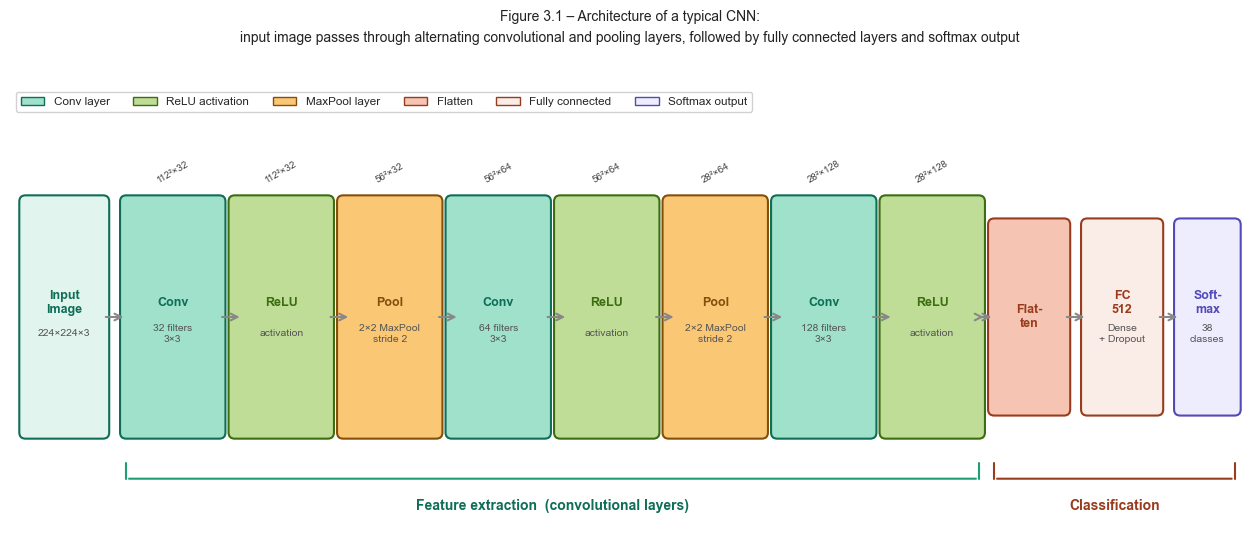

Saved → notebooks/plots/cnn_architecture.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np
from pathlib import Path

SAVE_PATH = Path("notebooks/plots/cnn_architecture.png")

fig, ax = plt.subplots(figsize=(16, 6), facecolor="white")
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis("off")

# ── HELPER FUNCTIONS ──────────────────────────────────────
def draw_block(ax, x, y, w, h, color, edgecolor, label, sublabel=None):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=1.5
    )
    ax.add_patch(rect)
    cy = y + h / 2
    if sublabel:
        ax.text(x + w/2, cy + 0.18, label,
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=edgecolor)
        ax.text(x + w/2, cy - 0.22, sublabel,
                ha="center", va="center",
                fontsize=7.5, color="#555555")
    else:
        ax.text(x + w/2, cy, label,
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=edgecolor)

def draw_arrow(ax, x1, x2, y=3.0):
    ax.annotate("",
                xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#888888",
                    lw=1.5
                ))

# ── INPUT IMAGE ───────────────────────────────────────────
draw_block(ax, 0.2, 1.5, 1.0, 3.0,
           "#E1F5EE", "#0F6E56",
           "Input\nImage",
           "224×224×3")

draw_arrow(ax, 1.2, 1.5)

# ── CONV + POOL BLOCKS ────────────────────────────────────
blocks = [
    # (x,    label,      sublabel,         color,     edge)
    (1.5,  "Conv",    "32 filters\n3×3",  "#9FE1CB", "#0F6E56"),
    (2.9,  "ReLU",   "activation",        "#C0DD97", "#3B6D11"),
    (4.3,  "Pool",   "2×2 MaxPool\nstride 2", "#FAC775", "#854F0B"),
    (5.7,  "Conv",   "64 filters\n3×3",   "#9FE1CB", "#0F6E56"),
    (7.1,  "ReLU",   "activation",        "#C0DD97", "#3B6D11"),
    (8.5,  "Pool",   "2×2 MaxPool\nstride 2", "#FAC775", "#854F0B"),
    (9.9,  "Conv",   "128 filters\n3×3",  "#9FE1CB", "#0F6E56"),
    (11.3, "ReLU",   "activation",        "#C0DD97", "#3B6D11"),
]

for i, (x, label, sublabel, color, edge) in enumerate(blocks):
    draw_block(ax, x, 1.5, 1.2, 3.0, color, edge, label, sublabel)
    draw_arrow(ax, x + 1.2, x + 1.5 if i < len(blocks)-1 else x + 1.3)

# arrow after last conv block
draw_arrow(ax, 11.3 + 1.2, 12.7)

# ── FLATTEN ───────────────────────────────────────────────
draw_block(ax, 12.7, 1.8, 0.9, 2.4,
           "#F5C4B3", "#993C1D",
           "Flat-\nten", None)
draw_arrow(ax, 13.6, 13.9)

# ── FC LAYER ──────────────────────────────────────────────
draw_block(ax, 13.9, 1.8, 0.9, 2.4,
           "#FAECE7", "#993C1D",
           "FC\n512", "Dense\n+ Dropout")
draw_arrow(ax, 14.8, 15.1)

# ── SOFTMAX OUTPUT ────────────────────────────────────────
draw_block(ax, 15.1, 1.8, 0.7, 2.4,
           "#EEEDFE", "#534AB7",
           "Soft-\nmax",
           "38\nclasses")

# ── BRACKET LABELS ────────────────────────────────────────
# Feature extraction bracket
ax.annotate("", xy=(12.5, 0.9), xytext=(1.5, 0.9),
            arrowprops=dict(arrowstyle="-", color="#1D9E75", lw=1.5))
ax.plot([1.5, 1.5],   [0.9, 1.1], color="#1D9E75", lw=1.5)
ax.plot([12.5, 12.5], [0.9, 1.1], color="#1D9E75", lw=1.5)
ax.text(7.0, 0.55,
        "Feature extraction  (convolutional layers)",
        ha="center", va="center",
        fontsize=10, color="#0F6E56", fontweight="bold")

# Classification bracket
ax.annotate("", xy=(15.8, 0.9), xytext=(12.7, 0.9),
            arrowprops=dict(arrowstyle="-", color="#993C1D", lw=1.5))
ax.plot([12.7, 12.7], [0.9, 1.1], color="#993C1D", lw=1.5)
ax.plot([15.8, 15.8], [0.9, 1.1], color="#993C1D", lw=1.5)
ax.text(14.25, 0.55,
        "Classification",
        ha="center", va="center",
        fontsize=10, color="#993C1D", fontweight="bold")

# ── TOP LABELS: feature map sizes ─────────────────────────
sizes = [
    (2.1,  "112²×32"),
    (3.5,  "112²×32"),
    (4.9,  "56²×32"),
    (6.3,  "56²×64"),
    (7.7,  "56²×64"),
    (9.1,  "28²×64"),
    (10.5, "28²×128"),
    (11.9, "28²×128"),
]
for xpos, label in sizes:
    ax.text(xpos, 4.72, label,
            ha="center", va="bottom",
            fontsize=7, color="#444444",
            rotation=30)

# ── LEGEND ────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor="#9FE1CB", edgecolor="#0F6E56", label="Conv layer"),
    mpatches.Patch(facecolor="#C0DD97", edgecolor="#3B6D11", label="ReLU activation"),
    mpatches.Patch(facecolor="#FAC775", edgecolor="#854F0B", label="MaxPool layer"),
    mpatches.Patch(facecolor="#F5C4B3", edgecolor="#993C1D", label="Flatten"),
    mpatches.Patch(facecolor="#FAECE7", edgecolor="#993C1D", label="Fully connected"),
    mpatches.Patch(facecolor="#EEEDFE", edgecolor="#534AB7", label="Softmax output"),
]
ax.legend(handles=legend_items,
          loc="upper left", bbox_to_anchor=(0.0, 1.0),
          fontsize=8.5, frameon=True,
          ncol=6, framealpha=0.9)

# ── TITLE ─────────────────────────────────────────────────
ax.set_title(
    "Figure 3.1 – Architecture of a typical CNN:\n"
    "input image passes through alternating convolutional and pooling layers, "
    "followed by fully connected layers and softmax output",
    fontsize=10, pad=32, linespacing=1.6, color="#222222"
)

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")

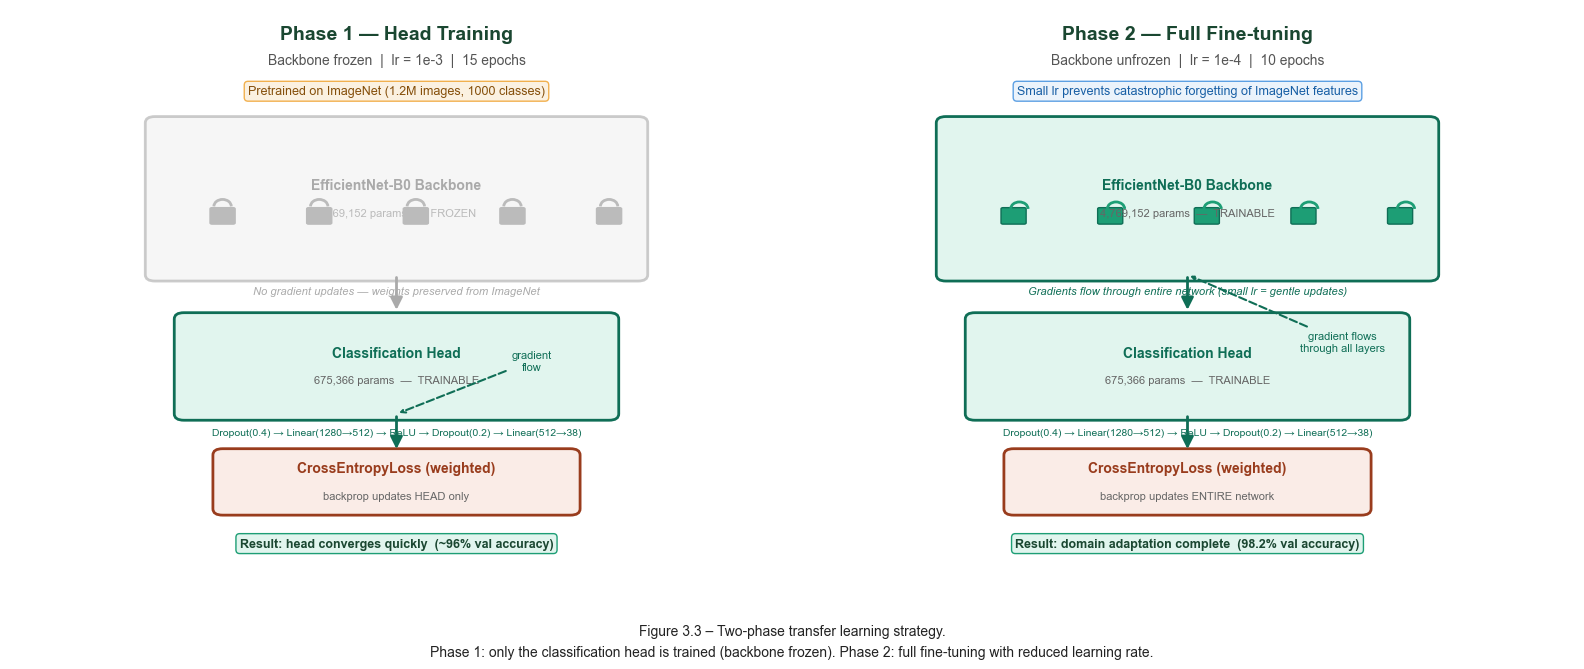

Saved → notebooks/plots/transfer_learning_phases.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from pathlib import Path

SAVE_PATH = Path("notebooks/plots/transfer_learning_phases.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")

# ═══════════════════════════════════════════════════════════
# HELPER
# ═══════════════════════════════════════════════════════════
def draw_block(ax, x, y, w, h, facecolor, edgecolor,
               label, sublabel=None, alpha=1.0):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=2,
        alpha=alpha
    )
    ax.add_patch(rect)
    cy = y + h / 2
    if sublabel:
        ax.text(x + w/2, cy + 0.22, label,
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=edgecolor if alpha == 1.0 else "#AAAAAA")
        ax.text(x + w/2, cy - 0.22, sublabel,
                ha="center", va="center",
                fontsize=8, color="#666666" if alpha == 1.0 else "#BBBBBB")
    else:
        ax.text(x + w/2, cy, label,
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=edgecolor if alpha == 1.0 else "#AAAAAA")

def draw_arrow(ax, x1, y1, x2, y2, color="#888888"):
    ax.annotate("",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=2.0,
                    mutation_scale=18
                ))

def lock_icon(ax, x, y, color="#999999"):
    """Рисует иконку замка"""
    # дужка
    circle = mpatches.Arc((x, y+0.18), 0.18, 0.22,
                           angle=0, theta1=0, theta2=180,
                           color=color, lw=2)
    ax.add_patch(circle)
    # корпус
    rect = mpatches.FancyBboxPatch(
        (x-0.11, y-0.08), 0.22, 0.22,
        boxstyle="round,pad=0.02",
        facecolor=color, edgecolor=color, linewidth=1
    )
    ax.add_patch(rect)

# ═══════════════════════════════════════════════════════════
# PHASE 1
# ═══════════════════════════════════════════════════════════
ax1 = axes[0]
ax1.set_xlim(0, 8)
ax1.set_ylim(0, 9)
ax1.axis("off")
ax1.set_facecolor("white")

# Title
ax1.text(4, 8.6, "Phase 1 — Head Training",
         ha="center", va="center",
         fontsize=14, fontweight="bold", color="#1a4731")
ax1.text(4, 8.2, "Backbone frozen  |  lr = 1e-3  |  15 epochs",
         ha="center", va="center",
         fontsize=10, color="#555555")

# ImageNet pretrained label
ax1.text(4, 7.7, "Pretrained on ImageNet (1.2M images, 1000 classes)",
         ha="center", va="center",
         fontsize=9, color="#854F0B",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="#FAEEDA", edgecolor="#EF9F27", alpha=0.8))

# Backbone — FROZEN (серый, полупрозрачный)
draw_block(ax1, 1.5, 4.8, 5.0, 2.4,
           "#F0F0F0", "#AAAAAA",
           "EfficientNet-B0 Backbone",
           "4,769,152 params  —  FROZEN",
           alpha=0.6)

# Lock icons
for lx in [2.2, 3.2, 4.2, 5.2, 6.2]:
    lock_icon(ax1, lx, 5.7, color="#BBBBBB")

# Frozen label
ax1.text(4.0, 4.55,
         "No gradient updates — weights preserved from ImageNet",
         ha="center", va="center",
         fontsize=8, color="#AAAAAA", style="italic")

# Arrow backbone → head
draw_arrow(ax1, 4.0, 4.8, 4.0, 4.2, color="#AAAAAA")

# Head — TRAINABLE (зелёный, яркий)
draw_block(ax1, 1.8, 2.6, 4.4, 1.5,
           "#E1F5EE", "#0F6E56",
           "Classification Head",
           "675,366 params  —  TRAINABLE")

# Head details
ax1.text(4.0, 2.3,
         "Dropout(0.4) → Linear(1280→512) → ReLU → Dropout(0.2) → Linear(512→38)",
         ha="center", va="center",
         fontsize=7.5, color="#0F6E56")

# Arrow head → loss
draw_arrow(ax1, 4.0, 2.6, 4.0, 2.0, color="#0F6E56")

# Loss box
draw_block(ax1, 2.2, 1.1, 3.6, 0.85,
           "#FAECE7", "#993C1D",
           "CrossEntropyLoss (weighted)",
           "backprop updates HEAD only")

# Gradient flow annotation
ax1.annotate("gradient\nflow",
             xy=(4.0, 2.6), xytext=(5.4, 3.3),
             arrowprops=dict(arrowstyle="->",
                             color="#0F6E56", lw=1.5,
                             linestyle="dashed"),
             fontsize=8, color="#0F6E56", ha="center")

# Result box
ax1.text(4.0, 0.55,
         "Result: head converges quickly  (~96% val accuracy)",
         ha="center", va="center",
         fontsize=9, color="#1a4731", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="#E1F5EE", edgecolor="#1D9E75"))

# ═══════════════════════════════════════════════════════════
# PHASE 2
# ═══════════════════════════════════════════════════════════
ax2 = axes[1]
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 9)
ax2.axis("off")
ax2.set_facecolor("white")

# Title
ax2.text(4, 8.6, "Phase 2 — Full Fine-tuning",
         ha="center", va="center",
         fontsize=14, fontweight="bold", color="#1a4731")
ax2.text(4, 8.2, "Backbone unfrozen  |  lr = 1e-4  |  10 epochs",
         ha="center", va="center",
         fontsize=10, color="#555555")

# Warning label
ax2.text(4, 7.7, "Small lr prevents catastrophic forgetting of ImageNet features",
         ha="center", va="center",
         fontsize=9, color="#185FA5",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="#E6F1FB", edgecolor="#378ADD", alpha=0.8))

# Backbone — UNFROZEN (зелёный, яркий)
draw_block(ax2, 1.5, 4.8, 5.0, 2.4,
           "#E1F5EE", "#0F6E56",
           "EfficientNet-B0 Backbone",
           "4,769,152 params  —  TRAINABLE",
           alpha=1.0)

# Unlock icons (зелёные)
for lx in [2.2, 3.2, 4.2, 5.2, 6.2]:
    # открытый замок — просто корпус без дужки сверху
    rect = mpatches.FancyBboxPatch(
        (lx-0.11, 5.62), 0.22, 0.22,
        boxstyle="round,pad=0.02",
        facecolor="#1D9E75", edgecolor="#0F6E56", linewidth=1
    )
    ax2.add_patch(rect)
    # открытая дужка (смещена вправо)
    arc = mpatches.Arc((lx+0.06, 5.84), 0.18, 0.22,
                       angle=0, theta1=0, theta2=180,
                       color="#1D9E75", lw=2)
    ax2.add_patch(arc)

ax2.text(4.0, 4.55,
         "Gradients flow through entire network (small lr = gentle updates)",
         ha="center", va="center",
         fontsize=8, color="#0F6E56", style="italic")

# Arrow backbone → head
draw_arrow(ax2, 4.0, 4.8, 4.0, 4.2, color="#0F6E56")

# Head — TRAINABLE
draw_block(ax2, 1.8, 2.6, 4.4, 1.5,
           "#E1F5EE", "#0F6E56",
           "Classification Head",
           "675,366 params  —  TRAINABLE")

ax2.text(4.0, 2.3,
         "Dropout(0.4) → Linear(1280→512) → ReLU → Dropout(0.2) → Linear(512→38)",
         ha="center", va="center",
         fontsize=7.5, color="#0F6E56")

# Arrow head → loss
draw_arrow(ax2, 4.0, 2.6, 4.0, 2.0, color="#0F6E56")

# Loss box
draw_block(ax2, 2.2, 1.1, 3.6, 0.85,
           "#FAECE7", "#993C1D",
           "CrossEntropyLoss (weighted)",
           "backprop updates ENTIRE network")

# Gradient flow annotation — через весь backbone
ax2.annotate("gradient flows\nthrough all layers",
             xy=(4.0, 4.8), xytext=(5.6, 3.6),
             arrowprops=dict(arrowstyle="->",
                             color="#0F6E56", lw=1.5,
                             linestyle="dashed"),
             fontsize=8, color="#0F6E56", ha="center")

# Result box
ax2.text(4.0, 0.55,
         "Result: domain adaptation complete  (98.2% val accuracy)",
         ha="center", va="center",
         fontsize=9, color="#1a4731", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="#E1F5EE", edgecolor="#1D9E75"))

# ── ОБЩИЙ ЗАГОЛОВОК ───────────────────────────────────────
fig.suptitle(
    "Figure 3.3 – Two-phase transfer learning strategy.\n"
    "Phase 1: only the classification head is trained (backbone frozen). "
    "Phase 2: full fine-tuning with reduced learning rate.",
    fontsize=10, y=0.02, linespacing=1.6, color="#222222"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")

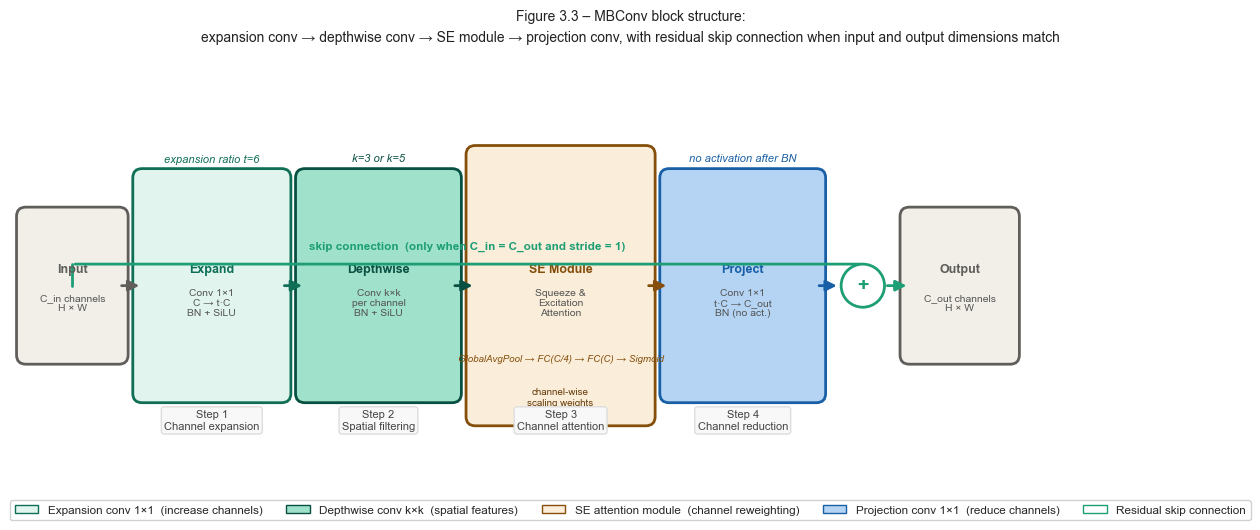

Saved → notebooks/plots/mbconv_block.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from pathlib import Path

SAVE_PATH = Path("notebooks/plots/mbconv_block.png")

fig, ax = plt.subplots(figsize=(16, 6), facecolor="white")
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis("off")

# ── HELPERS ───────────────────────────────────────────────
def block(ax, x, y, w, h, fc, ec, label, sub=None):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.12",
        facecolor=fc, edgecolor=ec,
        linewidth=2
    )
    ax.add_patch(rect)
    cy = y + h / 2
    if sub:
        ax.text(x + w/2, cy + 0.22, label,
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=ec)
        ax.text(x + w/2, cy - 0.22, sub,
                ha="center", va="center",
                fontsize=7.5, color="#555555")
    else:
        ax.text(x + w/2, cy, label,
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=ec)

def arrow(ax, x1, x2, y=3.0, color="#888888"):
    ax.annotate("",
                xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=2.0,
                    mutation_scale=16
                ))

def plus_circle(ax, x, y, r=0.28):
    circle = plt.Circle((x, y), r,
                         facecolor="white",
                         edgecolor="#1D9E75",
                         linewidth=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, "+",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color="#1D9E75", zorder=6)

# ── INPUT ─────────────────────────────────────────────────
block(ax, 0.2, 2.1, 1.2, 1.8,
      "#F1EFE8", "#5F5E5A",
      "Input",
      "C_in channels\nH × W")

arrow(ax, 1.4, 1.7, color="#5F5E5A")

# ── 1. EXPANSION CONV 1×1 ─────────────────────────────────
block(ax, 1.7, 1.6, 1.8, 2.8,
      "#E1F5EE", "#0F6E56",
      "Expand",
      "Conv 1×1\nC → t·C\nBN + SiLU")

# expansion ratio label
ax.text(2.6, 4.65,
        "expansion ratio t=6",
        ha="center", va="center",
        fontsize=8, color="#0F6E56", style="italic")

arrow(ax, 3.5, 3.8, color="#0F6E56")

# ── 2. DEPTHWISE CONV 3×3 ─────────────────────────────────
block(ax, 3.8, 1.6, 1.9, 2.8,
      "#9FE1CB", "#085041",
      "Depthwise",
      "Conv k×k\nper channel\nBN + SiLU")

ax.text(4.75, 4.65,
        "k=3 or k=5",
        ha="center", va="center",
        fontsize=8, color="#085041", style="italic")

arrow(ax, 5.7, 6.0, color="#085041")

# ── 3. SE MODULE ──────────────────────────────────────────
block(ax, 6.0, 1.3, 2.2, 3.4,
      "#FAEEDA", "#854F0B",
      "SE Module",
      "Squeeze &\nExcitation\nAttention")

# SE внутренняя схема
ax.text(7.1, 2.05,
        "GlobalAvgPool → FC(C/4) → FC(C) → Sigmoid",
        ha="center", va="center",
        fontsize=7, color="#854F0B", style="italic")

# SE — scale annotation
ax.text(7.1, 1.55,
        "channel-wise\nscaling weights",
        ha="center", va="center",
        fontsize=7, color="#633806")

arrow(ax, 8.2, 8.5, color="#854F0B")

# ── 4. PROJECTION CONV 1×1 ────────────────────────────────
block(ax, 8.5, 1.6, 1.9, 2.8,
      "#B5D4F4", "#185FA5",
      "Project",
      "Conv 1×1\nt·C → C_out\nBN (no act.)")

ax.text(9.45, 4.65,
        "no activation after BN",
        ha="center", va="center",
        fontsize=8, color="#185FA5", style="italic")

arrow(ax, 10.4, 10.7, color="#185FA5")

# ── ADD (residual) ────────────────────────────────────────
plus_circle(ax, 11.0, 3.0)

arrow(ax, 11.28, 11.6, color="#1D9E75")

# ── OUTPUT ────────────────────────────────────────────────
block(ax, 11.6, 2.1, 1.3, 1.8,
      "#F1EFE8", "#5F5E5A",
      "Output",
      "C_out channels\nH × W")

# ── RESIDUAL SKIP CONNECTION ──────────────────────────────
# линия сверху от input к +
ax.annotate("",
            xy=(11.0, 3.28), xytext=(0.8, 3.28),
            arrowprops=dict(
                arrowstyle="-",
                color="#1D9E75",
                lw=2.0,
            ))
ax.plot([0.8, 0.8], [3.0, 3.28],
        color="#1D9E75", lw=2.0)
ax.plot([11.0, 11.0], [3.28, 3.28],
        color="#1D9E75", lw=2.0)

ax.text(5.9, 3.52,
        "skip connection  (only when C_in = C_out and stride = 1)",
        ha="center", va="center",
        fontsize=8.5, color="#1D9E75", fontweight="bold")

# ── LABELS BELOW BLOCKS ───────────────────────────────────
details = [
    (2.6,  "Step 1\nChannel expansion"),
    (4.75, "Step 2\nSpatial filtering"),
    (7.1,  "Step 3\nChannel attention"),
    (9.45, "Step 4\nChannel reduction"),
]
for xpos, label in details:
    ax.text(xpos, 1.25, label,
            ha="center", va="center",
            fontsize=8, color="#444444",
            bbox=dict(boxstyle="round,pad=0.25",
                      facecolor="#F8F8F8",
                      edgecolor="#DDDDDD"))

# ── LEGEND ────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor="#E1F5EE", edgecolor="#0F6E56",
                   label="Expansion conv 1×1  (increase channels)"),
    mpatches.Patch(facecolor="#9FE1CB", edgecolor="#085041",
                   label="Depthwise conv k×k  (spatial features)"),
    mpatches.Patch(facecolor="#FAEEDA", edgecolor="#854F0B",
                   label="SE attention module  (channel reweighting)"),
    mpatches.Patch(facecolor="#B5D4F4", edgecolor="#185FA5",
                   label="Projection conv 1×1  (reduce channels)"),
    mpatches.Patch(facecolor="white",   edgecolor="#1D9E75",
                   label="Residual skip connection"),
]
ax.legend(handles=legend_items,
          loc="lower center",
          bbox_to_anchor=(0.5, -0.02),
          fontsize=8.5, ncol=5,
          frameon=True, framealpha=0.9)

# ── TITLE ─────────────────────────────────────────────────
ax.set_title(
    "Figure 3.3 – MBConv block structure:\n"
    "expansion conv → depthwise conv → SE module → projection conv, "
    "with residual skip connection when input and output dimensions match",
    fontsize=10, pad=10, linespacing=1.6, color="#222222"
)

# ── SAVE ──────────────────────────────────────────────────
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=180,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none")
plt.show()
print(f"Saved → {SAVE_PATH}")